<a href="https://colab.research.google.com/github/Yan-cabore/Atividades_Visao_Computacional_iRede/blob/main/atividade03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade 3: **Filtragem de imagens e análise de ruídos**
___




## Aluno: Carlos Yan Matos Ferreira

## Dataset:

### Classes:
* **Classe A** — Cubo Mágico
  * **Justificativa:** bom para visualizar como múltiplas cores se comportam durante as operações. Útil para realizar análises que envolvam segmentação ou detecção de bordas.


* **Classe B** — Cartas de baralho
  * **Justificativa:** mais fácil de simular erros, como amassos e reflexos de flash ou luz. Além disso, caso o conjunto de dados possa ser utilizado futuramente, há interesse em desenvolver um modelo que reconheça falhas em cartas.
---

## Registro de imagens:

### **Classe A**:

| Título | Local | Distância | Iluminação | Condição |
| :----: | :---: | :-------: | :--------: | :------: |
|cubo1.jpeg     |IFCE   |1 a 34cm           |Artificial            | Desfoque         |
|cubo2.jpeg        |IFCE   |1 a 16cm           |Natural            |Baixa Resolução          |
|cubo3.jpeg          |IFCE   |1 a 29cm           |Natural            |Boa          |
|cubo4.jpeg        |IFCE   |1 a 19cm          |Artificial            |Boa          |
|cubo5.jpeg      |IFCE   |1 a 17cm           |Artificial            |Baixa Resolução          |

### **Classe B**:

| Título | Local | Distância | Iluminação | Condição |
| :----: | :---: | :-------: | :--------: | :------: |
|carta1.jpeg     |IFCE   |1 a 12cm           |Artificial            |Reflexo no objeto          |
|carta2.jpeg        |IFCE   |1 a 8cm           |Artificial            |Reflexo no objeto          |
|carta3.jpeg        |IFCE   |1 a 108cm           |Natural            |Baixa Resolução          |
|carta4.jpeg        |IFCE   |1 a 18cm           |Natural            | Boa         |
|carta5.jpeg        |IFCE   |1 a 33cm           |Artificial            |Boa          |
---

## Câmera e captura:

*  Motorola Moto G35 5G — câmera principal 50 MP | f/1,8 | lente 74,2°

* Para imagens com iluminação artificial, utilizei espaços fechados, majoritariamente iluminados por lâmpadas ou lanternas. Para imagens com iluminação natural, posicionei os objetos ao ar livre e os registrei, aproveitando a luz do sol.

## Imagens selecionadas:

### **Classe A**:
- cubo4.jpeg:
  - Formato: JPEG

  - Ruído Original: A imagem não possui um ruído original significativo; foi uma das que tentei registrar com a melhor qualidade possível.

  - Resolução: 1280x720

  - Justificativa: A imagem está bem enquadrada e é possível analisar o objeto sem muitas distrações.
  
### **Classe B**:
- carta1.jpeg:
  - Formato: JPEG

  - Ruído Original: A imagem possui um estouro de luz no objeto (carta).

  - Resolução: 720x1280

  - Justificativa: A presença de um "padrão natural" de textura (semelhante a sal e pimenta) no fundo da imagem. O objetivo é analisar se, ao aplicar ruídos, o fundo se tornará ainda mais difícil de atenuar com outros filtros, ou se os ruídos serão capazes de diminuir tanto o padrão natural quanto o artificial.

## Ferramentas próprias:
- Utilizei a classe que criei no notebook anterior. Agora ela se chama VisionUtils. Após consultar colegas, fui informado de que o nome 'Utils' era um tanto genérico. Mantive os métodos da versão anterior, mas busquei torná-los ainda mais robustos. Abaixo, segue a lista dos métodos implementados.

  1. Leitura das imagens selecionadas
  2. Conversão das imagens de BGR para RGB
  3. Criação de figuras
  4. Preenchimento de figuras com as imagens lidas
  5. Nomear eixos criados dentro das figuras
  6. Remoção dos eixos presentes dentro das figuras (linhas métricas)
  7. Adição de imagens em eixos criados anteriormente
  8. Quantização dos níveis de intensidade
  9. Introdução de ruído sal e pimenta

## Nota:
- Todos os métodos da classe estão comentados em seu código, a fim de evitar a necessidade de justificá-los durante a execução da atividade e, assim, manter as células mais organizadas.
---

# VisionUtils:

In [ ]:
class VisionUtils():

  def __init__(self):
    return

  def ler_imagens(self, img_list: list, type=None): # método para ler as imagens

    for i in range(len(img_list)): # decidi passar as imagens como uma lista de nomes para iterar sobre.
      img_list[i] = cv.imread(img_list[i], cv.IMREAD_COLOR_RGB) # lendo imagem por imagem
      # o cv.IMREAD já lê como RGB

    return img_list

  def criar_figure(self, fig_name, axes_x, axes_y, fig_size): # método para criar figure (retorna axes 1D ou 2D dependendo de axes_x, axes_y)
    fig, ax = plt.subplots(axes_x, axes_y, figsize=fig_size, squeeze=False)
    fig.suptitle(fig_name)
    fig.tight_layout() # método para deixar a figure criada mais normalizada

    return fig, ax
                                                  # cmap ficou como None porque só preciso dele em gray
  def preencher_figure(self, axe, img_list: list, cmap=None): # método para preencher axes 1D ou 2D com as imagens
    for i, linha in enumerate(axe): # preenchimento de cada axe na figure
      for j, ax in enumerate(linha): # explicação do laço abaixo
        ax.imshow(img_list[i][j], cmap=cmap)

  def nomear_axes(self, axe, names: list): # método para nomear cada um dos axes (1D ou 2D)
    for i, linha in enumerate(axe): # itero sobre cada linha da grade de axes
      for j, ax in enumerate(linha): # itero sobre cada axe dentro da linha
        ax.set_title(names[i][j]) # nomear
    return

  def remover_axis(self, axe): # método para remover os axis da figure, seguindo o padrão ensinado pelo professor
    for a in axe:
      a.axis('off')
    return

  def adicionar_imagem(self, axe, img): # método para adicionar imagem a axes vazios
    for ax in axe:
      if not ax.has_data(): # a ideia é percorrer cada um usando o método has_data, que informa se o axe está preenchido ou não
        ax.imshow(img) # preenche o axe quando vazio
        break          # se não houvesse break, o laço preencheria qualquer axe vazio
    return               # no momento em que ele preenche um espaço, o laço quebra
                         # assim, adiciono só uma imagem em um axe por vez


  # método para contar quantidade dos níveis de uma imagem
  def qtd_gray(self, imgs: list):

    # Cria uma cópia da lista de imagens para não modificar a original durante a conversão
    # e garantir que as imagens originais na lista 'imagens_suavizadas' permaneçam coloridas se necessário posteriormente.
    imgs_gray = [cv.cvtColor(img, cv.COLOR_RGB2GRAY) for img in imgs] # Converte todas as imagens para cinza

    qtds = []

    for img_gray in imgs_gray:
      qtds.append(len(np.unique(img_gray)))   # extrai os níveis de tom de cinza

    return qtds # retorna os níveis

  # retirado do notebook exemplo do professor
  def ruido_gaussiano(self, img, media, desvio_padrao):

    # a média define para onde os pixels tendem a variar
    # o desvio padrão define o quanto eles podem variar
    noise = np.random.normal(media, desvio_padrao, img.shape)
    img_ruido = img + noise
    img_ruido = np.clip(img_ruido, 0, 255) # remove valores que saíram do intervalo de 0 a 255
    return img_ruido.astype(np.uint8)

  # método para introduzir ruído sal e pimenta
  # o código foi copiado do notebook provido pelos professores
  # diante disso, não vou comentar sobre ele
  def salt_and_pepper_noise(self, img, noise_rate):
    noisy_image = np.copy(img)
    min_value, max_value = 0, 255

    total_pixels = noisy_image.size
    num_noisy_pixels = int(total_pixels * noise_rate)

    noisy_pixel_indices = np.random.choice(total_pixels, num_noisy_pixels, replace=False)

    pepper_indices = noisy_pixel_indices[::2]
    noisy_image.flat[pepper_indices] = min_value

    salt_indices = noisy_pixel_indices[1::2]
    noisy_image.flat[salt_indices] = max_value

    return noisy_image

  # método para aplicar a transformada de fourier e centralizar o espectro
  def fourier(self, img):
    f = np.fft.fft2(img)
    f_shift = np.fft.fftshift(f)
    mag_spec = np.log(1 + np.abs(f_shift))
    return mag_spec

## Dependências e imagens:

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

vision = VisionUtils()

In [ ]:
# Primeira imagem
upload_1 = files.upload()

Saving carta5.jpeg to carta5 (1).jpeg
Saving carta4.jpeg to carta4 (1).jpeg
Saving carta3.jpeg to carta3 (1).jpeg
Saving carta2.jpeg to carta2 (1).jpeg
Saving carta1.jpeg to carta1 (1).jpeg


In [ ]:
# Segunda imagem
upload_2 = files.upload()

Saving cubo5.jpeg to cubo5 (1).jpeg
Saving cubo4.jpeg to cubo4 (1).jpeg
Saving cubo3.jpeg to cubo3 (1).jpeg
Saving cubo2.jpeg to cubo2 (1).jpeg
Saving cubo1.jpeg to cubo1 (1).jpeg


## Imagens no domínio do espectro

### Classe A

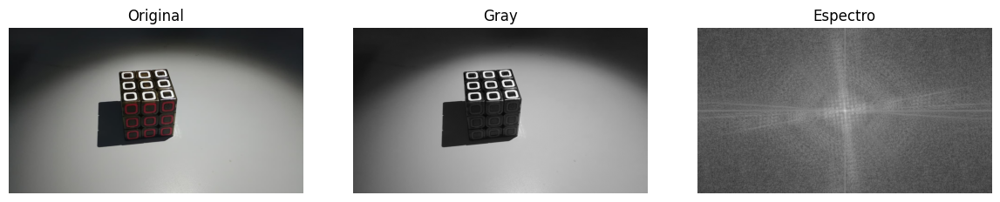

In [ ]:
# Leitura da imagem
cb_original = cv.imread('cubo4.jpeg', cv.IMREAD_COLOR_RGB)

# Criando uma gray, para aplicar a fft
cb_gray = cv.cvtColor(cb_original, cv.COLOR_BGR2GRAY)

# Aplicando Transformada de Fourier
cb_spec = vision.fourier(cb_gray)

# Criando lista pra poder aplicar métodos da VisionUtils
imgs_A = [
    [cb_original, cb_gray, cb_spec]
    ]

# Criação da figure
fig, ax = vision.criar_figure('', 1, 3, (12, 5))

# Corrigindo o formato de ax para 2D e usando imgs_A diretamente
vision.preencher_figure(ax, imgs_A, cmap='gray')

# Corrigindo o formato de ax para 2D
vision.nomear_axes(ax, [['Original', 'Gray', 'Espectro']])
vision.remover_axis(ax.flatten()) # transforma de um arr 1D para 2D novamente

### Classe B

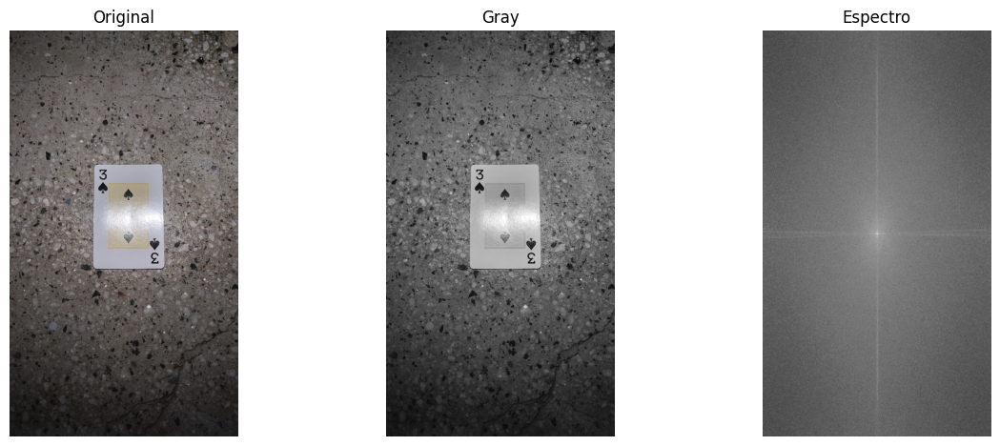

In [ ]:
# Repetição da lógica anterior
ct_original = cv.imread('carta1.jpeg', cv.IMREAD_COLOR_RGB)

ct_gray = cv.cvtColor(ct_original, cv.COLOR_BGR2GRAY)

f = np.fft.fft2(ct_gray)
ct_f = np.fft.fftshift(f)
ct_spec = np.log(1 + np.abs(ct_f))

imgs_A = [
    [ct_original, ct_gray, ct_spec]
    ]

fig, ax = vision.criar_figure('', 1, 3, (12, 5))

vision.preencher_figure(ax, imgs_A, cmap='gray')

vision.nomear_axes(ax, [['Original', 'Gray', 'Espectro']])
vision.remover_axis(ax.flatten())

### Observações:

# Introdução de ruídos:

## Gaussiano

## Classe A
- Nota: Decidi introduzir o ruído no início da classe A para evitar a replicação de código nas próximas células.

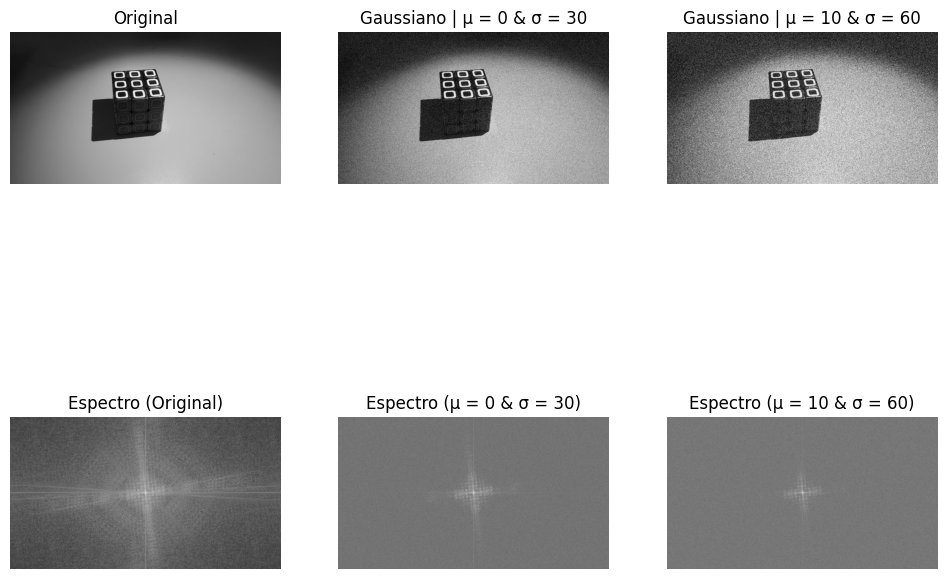

In [ ]:

# média = 0 || desvio = 30
cb_gray_1 = vision.ruido_gaussiano(cb_gray, 0, 30)  # cubo
ct_gray_1 = vision.ruido_gaussiano(ct_gray, 0, 30)  # carta

# média = 10 || desvio = 60
cb_gray_2 = vision.ruido_gaussiano(cb_gray, 10, 60) # cubo
ct_gray_2 = vision.ruido_gaussiano(ct_gray, 10, 60) # carta

# aplicando fft

cb_spec_1 = vision.fourier(cb_gray_1)
ct_spec_1 = vision.fourier(ct_gray_1)

cb_spec_2 = vision.fourier(cb_gray_2)
ct_spec_2 = vision.fourier(ct_gray_2)

# ---------------------------------------------------------- #


# Preparação pra plotar as imagens

imgs_ruidosas = [
    [cb_gray, cb_gray_1, cb_gray_2],
    [cb_spec, cb_spec_1, cb_spec_2]
]

nomes = [
    ['Original', 'Gaussiano | μ = 0 & σ = 30', 'Gaussiano | μ = 10 & σ = 60'],
    ['Espectro (Original)', 'Espectro (μ = 0 & σ = 30)', 'Espectro (μ = 10 & σ = 60)']
]

fig, ax = vision.criar_figure('', 2, 3, (10, 8))
vision.preencher_figure(ax, imgs_ruidosas, cmap='gray')
vision.nomear_axes(ax, nomes)
vision.remover_axis(ax.flatten())

## Classe B

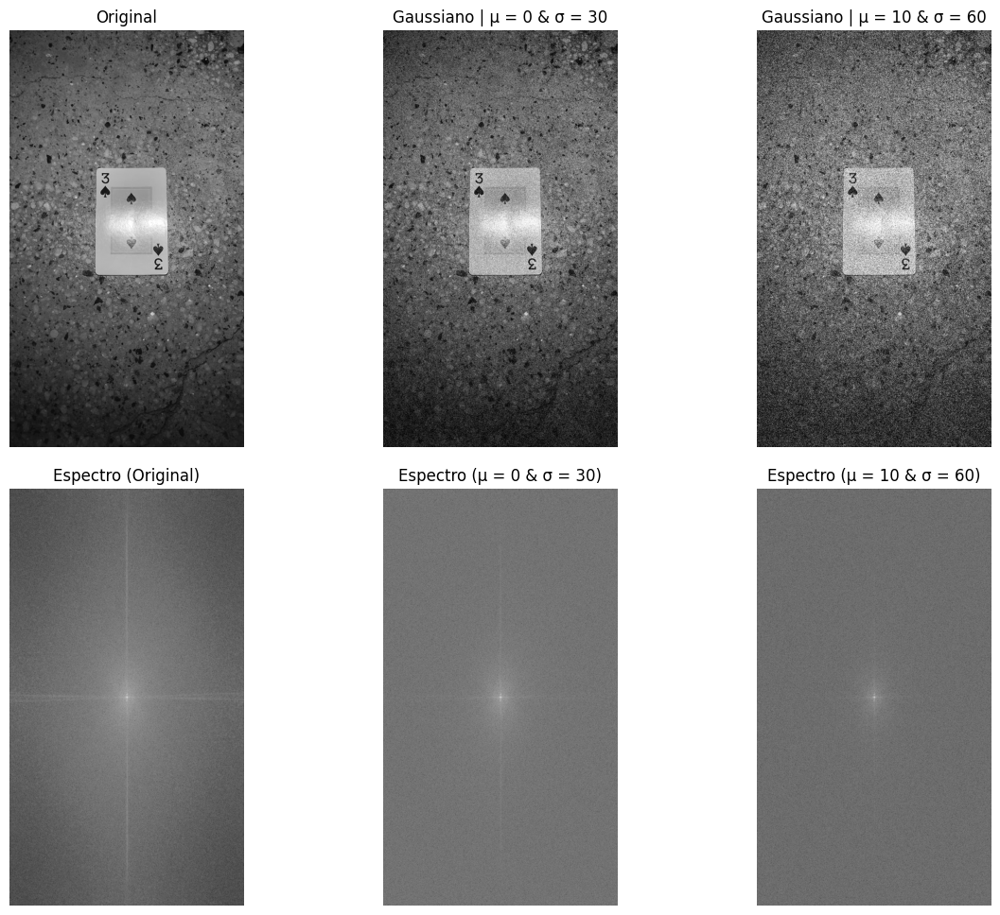

In [ ]:
# Reaproveitamento da lógica anterior
imgs_ruidosas = [
    [ct_gray, ct_gray_1, ct_gray_2],
    [ct_spec, ct_spec_1, ct_spec_2]
]

nomes = [
    ['Original', 'Gaussiano | μ = 0 & σ = 30', 'Gaussiano | μ = 10 & σ = 60'],
    ['Espectro (Original)', 'Espectro (μ = 0 & σ = 30)', 'Espectro (μ = 10 & σ = 60)']
]


fig, ax = vision.criar_figure('', 2, 3, (12, 10))
vision.preencher_figure(ax, imgs_ruidosas, cmap='gray')
vision.nomear_axes(ax, nomes)
vision.remover_axis(ax.flatten())


### Observações sobre Ruído Gaussiano - Classe A (Cubo)

#### Imagem: `cubo4.jpeg`

*   **Parâmetros utilizados:**
    *   Média (μ): 0, Desvio Padrão (σ): 30
    *   Média (μ): 10, Desvio Padrão (σ): 60
*   **Impacto visual observado:**

    *   Com os primeiros parâmetros, a imagem me lembrou bastante o filme 'O Exorcista'. A imagem ficou granulada, mas eu fiquei satisfeito com o visual que ela adquiriu, parece uma fotografia antiga. As sombras parecem ter ganhado um pouco de intensidade, além do contorno ter ficado menos suave, os detalhes dos quadrados mais escuros do cubo diminuíram. Com os parâmetros maiores, os contornos da sombra ficaram ainda menos suaves, os detalhes dos quadrados sombreados no cubo sumiram completamente.
*   **Perguntas para responder:**

    *   O ruído está distribuído uniformemente na imagem: Sim, é possível notar como o filtro se distribuiu bem. Mesmo nas regiões mais escuras, o filtro é visível, demonstrando ter acrescentado pequenos pontos de intensidade.

---
### Observações sobre Ruído Gaussiano - Classe B (Carta)

#### Imagem: `carta1.jpeg`

*   **Parâmetros utilizados:**
    *   Média (μ): 0, Desvio Padrão (σ): 30
    *   Média (μ): 10, Desvio Padrão (σ): 60
*   **Impacto visual observado:**

    *   Com os parâmetros menores, a imagem ficou granulada, sendo possível observar como a granulação ficou mais perceptível na carta ao centro. Analisando o fundo da imagem, percebe-se que o efeito pode passar despercebido, além do fato de que os pequenos pontos do fundo ficaram menos nítidos. Com os parâmetros maiores, o ruído fica bem mais aparente e o fundo da imagem tem seus pequenos pontos ainda mais ofuscados. Ainda, algumas rachaduras no chão se perdem completamente.
*   **Perguntas para responder:**
    
    *   O ruído está distribuído uniformemente na imagem: Sim, o efeito do ruído gaussiano ficou uniforme por toda a imagem, tanto com os parâmetros menores quanto maiores.
---

### Observações sobre o Espectro de Fourier - Classe A (Cubo) e Classe B (Carta)

*   **Impacto do Ruído Gaussiano no Espectro de Fourier:**
    
    *   ```cubo4.jpeg```: O ruído parece distribuído mais nas frequências de alta intensidade no espectro, o que fez com que ele, como um todo, tivesse sua intensidade levemente elevada, resultando em um tom cinza mais claro. Esse efeito aumentou conforme os valores dos parâmetros também aumentaram.

    *   ```carta1.jpeg```: O ruído tornou o espectro muito homogêneo. Como o fundo já possuía uma intensidade padronizada, sendo a carta e as sombras as únicas discrepâncias, o espectro ficou bem distribuído, já que o ruído variou aleatoriamente os valores de intensidade na imagem, introduzindo novas frequências de alto valor.

*   **Comparação entre Classes:**
    *   Inicialmente, os espectros apresentam grandes diferenças entre si. Ambos exibem o padrão em cruz, associado ao vazamento espectral causado pelas bordas do quadro da imagem, e reforçado por contornos retos alinhados aos eixos horizontal/vertical presentes no objeto fotografado. O cubo apresenta uma cruz mais intensa, provavelmente devido às suas quinas bem definidas, retas e de alto contraste. Já a carta apresenta uma cruz mais fina, por ser um objeto mais plano e homogêneo, com menos contornos de alto contraste alinhados aos eixos.
---

   ## Que tipo de problema esse ruído pode causar para algoritmos de visão computacional:
   * O ruído gaussiano demonstrou ter a capacidade de ofuscar detalhes importantes na imagem, especialmente as bordas. Observando a imagem ```carta1.jpeg```, percebe-se como as rachaduras no chão somem cada vez mais com a aplicação do ruído. Algo semelhante acontece com a imagem ```cubo4.jpeg```, que perde completamente os detalhes dos pequenos quadrados no lado sombreado. Dentro de uma pipeline de processamento, uma imagem com esse tipo de ruído pode dificultar processos que necessitem de detalhes precisos. Detecção de bordas, segmentação e extração de características são etapas que seriam prejudicadas pela presença desse tipo de ruído.

## Sal e Pimenta

## Classe A

--- Pixels Alterados (Sal e Pimenta) - Classe A (Cubo) ---
Cubo (5%): 46080 de 921600 pixels alterados (5.00%)
Cubo (50%): 460793 de 921600 pixels alterados (50.00%)
----------------------------------------------------------


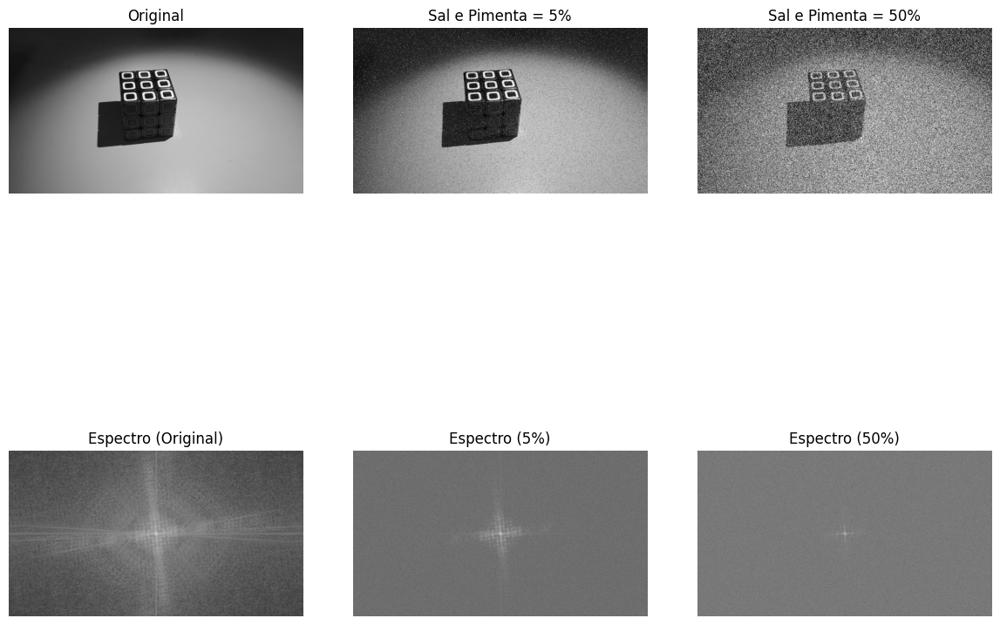

In [ ]:
# Sal e Pimenta - Classe A (Cubo)

# noise_rate = 5%
cb_gray_sp1 = vision.salt_and_pepper_noise(cb_gray, 0.05) # cubo

# noise_rate = 50%
cb_gray_sp2 = vision.salt_and_pepper_noise(cb_gray, 0.5) # cubo

# Aplicando fft
cb_spec_sp1 = vision.fourier(cb_gray_sp1)
cb_spec_sp2 = vision.fourier(cb_gray_sp2)

# ---------------------------------------------------------- #

# Cálculo da quantidade de pixels alterados para Cubo
print("--- Pixels Alterados (Sal e Pimenta) - Classe A (Cubo) ---")

# Cubo - 5%
pixels_alterados_cb_sp1 = np.sum(cb_gray != cb_gray_sp1)
total_pixels_cb = cb_gray.size
proporcao_cb_sp1 = pixels_alterados_cb_sp1 / total_pixels_cb
print(f"Cubo (5%): {pixels_alterados_cb_sp1} de {total_pixels_cb} pixels alterados ({proporcao_cb_sp1:.2%})")

# Cubo - 50%
pixels_alterados_cb_sp2 = np.sum(cb_gray != cb_gray_sp2)
proporcao_cb_sp2 = pixels_alterados_cb_sp2 / total_pixels_cb
print(f"Cubo (50%): {pixels_alterados_cb_sp2} de {total_pixels_cb} pixels alterados ({proporcao_cb_sp2:.2%})")

print("----------------------------------------------------------")

# Preparação para plotar as imagens

imgs_ruidosas = [
    [cb_gray, cb_gray_sp1, cb_gray_sp2],
    [cb_spec, cb_spec_sp1, cb_spec_sp2]
]

nomes = [
    ['Original', 'Sal e Pimenta = 5%', 'Sal e Pimenta = 50%'],
    ['Espectro (Original)', 'Espectro (5%)', 'Espectro (50%)']
]

fig, ax = vision.criar_figure('', 2, 3, (12, 10))
vision.preencher_figure(ax, imgs_ruidosas, cmap='gray')
vision.nomear_axes(ax, nomes)
vision.remover_axis(ax.flatten())

## Classe B

--- Pixels Alterados (Sal e Pimenta) - Classe B (Carta) ---
Carta (5%): 46071 de 921600 pixels alterados (5.00%)
Carta (50%): 460680 de 921600 pixels alterados (49.99%)
----------------------------------------------------------


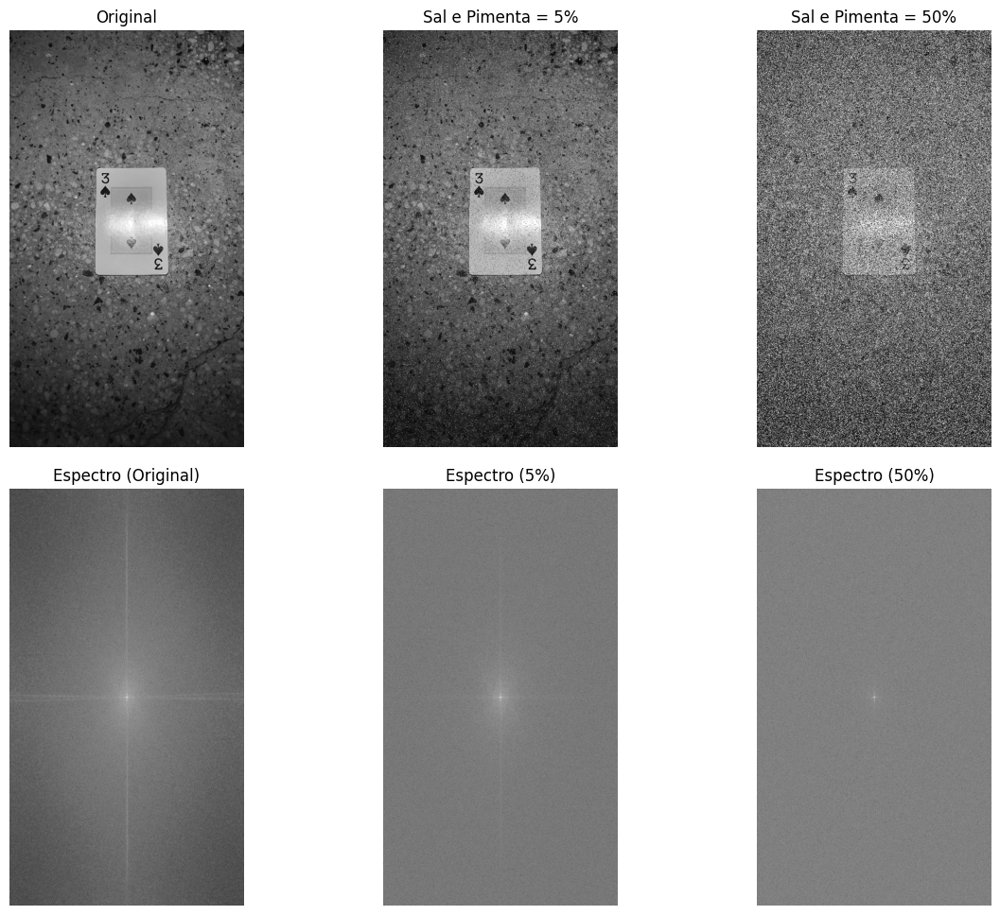

In [ ]:
# Sal e Pimenta - Classe B (Carta)

# noise_rate = 5%
ct_gray_sp1 = vision.salt_and_pepper_noise(ct_gray, 0.05) # carta

# noise_rate = 50%
ct_gray_sp2 = vision.salt_and_pepper_noise(ct_gray, 0.5) # carta

# Aplicando fft
ct_spec_sp1 = vision.fourier(ct_gray_sp1)
ct_spec_sp2 = vision.fourier(ct_gray_sp2)

# ---------------------------------------------------------- #

# Cálculo da quantidade de pixels alterados para Carta
print("--- Pixels Alterados (Sal e Pimenta) - Classe B (Carta) ---")

# Carta - 5%
pixels_alterados_ct_sp1 = np.sum(ct_gray != ct_gray_sp1)
total_pixels_ct = ct_gray.size
proporcao_ct_sp1 = pixels_alterados_ct_sp1 / total_pixels_ct
print(f"Carta (5%): {pixels_alterados_ct_sp1} de {total_pixels_ct} pixels alterados ({proporcao_ct_sp1:.2%})")

# Carta - 50%
pixels_alterados_ct_sp2 = np.sum(ct_gray != ct_gray_sp2)
proporcao_ct_sp2 = pixels_alterados_ct_sp2 / total_pixels_ct
print(f"Carta (50%): {pixels_alterados_ct_sp2} de {total_pixels_ct} pixels alterados ({proporcao_ct_sp2:.2%})")

print("----------------------------------------------------------")

# Preparação para plotar as imagens
imgs_ruidosas = [
    [ct_gray, ct_gray_sp1, ct_gray_sp2],
    [ct_spec, ct_spec_sp1, ct_spec_sp2]
]

nomes = [
    ['Original', 'Sal e Pimenta = 5%', 'Sal e Pimenta = 50%'],
    ['Espectro (Original)', 'Espectro (5%)', 'Espectro (50%)']
]

fig, ax = vision.criar_figure('', 2, 3, (12, 10))
vision.preencher_figure(ax, imgs_ruidosas, cmap='gray')
vision.nomear_axes(ax, nomes)
vision.remover_axis(ax.flatten())

### Registro: Pixels Alterados (Ruído Sal e Pimenta)

#### Classe A (Cubo)

*   **Imagem:** `cubo4.jpeg`
    *   **Taxa de Ruído (noise_rate) = 5%:**
        *   **Pixels Alterados:** 46080 de 921600 pixels (5.00%)

    *   **Taxa de Ruído (noise_rate) = 50%:**
        *   **Pixels Alterados:** 460795 de 921600 pixels (50.00%)

#### Classe B (Carta)

*   **Imagem:** `carta1.jpeg`
    *   **Taxa de Ruído (noise_rate) = 5%:**
        *   **Pixels Alterados:** 46070 de 921600 pixels (5.00%)
        *   **Observações:**

    *   **Taxa de Ruído (noise_rate) = 50%:**
        *   **Pixels Alterados:** 460677 de 921600 pixels (49.99%)

---

### Observações sobre Ruído Sal e Pimenta:

*   **Como esse ruído se diferencia visualmente do ruído gaussiano?**
    
    * Enquanto o ruído gaussiano os valores dos pixels de forma gradativa, dando a aparência granulada às imagens, o ruído sal e pimenta seleciona valores e simplesmente zera ou maximiza eles (0 ou 255). Isso faz com que a imagem fique bem mais ruidosa, devido a variação brusca dos pixels alterados.   

*   **Em quais situações esse ruído aparece em sistemas reais de captura de imagem?**
    *   Pesquisado de fontes externas:
        * **Gaussiano**: Simula fontes de ruídos comum do dia a dia, como sensores térmicos, problemas no sensor da câmera, baixa luminosidade, etc.

        * **Sal e Pimenta**: Simula erros de captura e transmissão de imagens, que geram pixels mortos ou perda de informação.

## Aplicação de Filtros:

In [ ]:
# Criação de classe para aplicar os filtros, facilitando reutilização de código

class GaussFilters():
  def passa_baixa_gaussiano(self, img, sigma):
    rows, cols = img.shape
    crow, ccol = rows // 2, cols // 2

    # grade de coordenadas
    x, y = np.ogrid[:rows, :cols]

    # distância ao quadrado ao centro
    dist2 = (x - crow) ** 2 + (y - ccol) ** 2

    # máscara gaussiana
    low_pass = np.exp(-dist2 / (2 * sigma ** 2))

    return low_pass

  # método para criar a máscara de filtro passa-alta gaussiano
  def passa_alta_gaussiano(self, img, sigma):
    low_pass = self.passa_baixa_gaussiano(img, sigma)
    high_pass = 1 - low_pass

    return high_pass

### Visualização da máscara de cada filtro

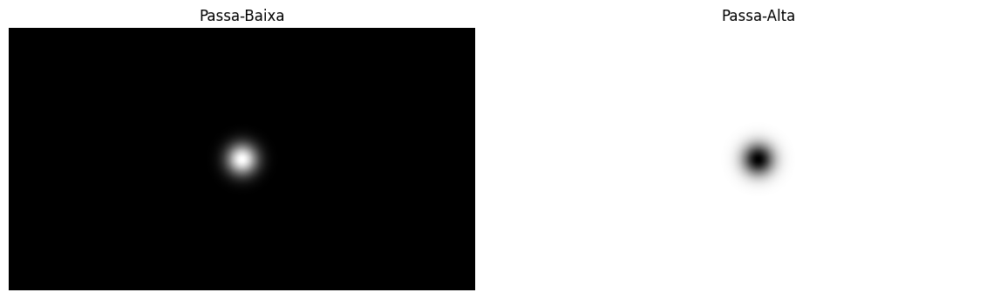

In [ ]:
# Passa-Baixa Gaussiano
rows, cols = cb_gray.shape
crow, ccol = rows // 2, cols // 2
sigma1 = 30
sigma2 = 60

# grade de coordenadas
x, y = np.ogrid[:rows, :cols]

# distância ao quadrado ao centro
dist2 = (x - crow) ** 2 + (y - ccol) ** 2

# máscara gaussiana
low_pass_1 = np.exp(-dist2 / (2 * sigma1 ** 2))
low_pass_2 = np.exp(-dist2 / (2 * sigma2 ** 2))

# Passa-Alta Gaussiana
high_pass_1 = 1 - low_pass_1
high_pass_2 = 1 - low_pass_2

# Passa-Faixa Gaussiana
rows, cols = cb_gray.shape
crow, ccol = rows // 2, cols // 2

x, y = np.ogrid[:rows, :cols]
dist2 = (x - crow) ** 2 + (y - ccol) ** 2

sigma_baixo = 10   # corta as frequências muito baixas
sigma_alto = 40    # corta as frequências muito altas

passa_baixa_larga = np.exp(-dist2 / (2 * sigma_alto ** 2))   # deixa passar até frequências mais altas
passa_baixa_estreita = np.exp(-dist2 / (2 * sigma_baixo ** 2))  # deixa passar só frequências bem baixas

band_pass = passa_baixa_larga - passa_baixa_estreita

nomes = [['Passa-Baixa', 'Passa-Alta']]
imgs = [[low_pass_1, high_pass_1]]

fig, ax = vision.criar_figure('', 1, 2, (12, 5))
vision.preencher_figure(ax, imgs, cmap='gray')
vision.nomear_axes(ax, nomes)
vision.remover_axis(ax.flatten())

# Aplicação de filtros para Ruído Gaussiano

In [ ]:
filtro = GaussFilters()

# PASSA BAIXA
#------------------------------------------------------------------#
cb1_low_30 = filtro.passa_baixa_gaussiano(cb_spec_1, 30) # Sigma = 30
cb2_low_30 = filtro.passa_baixa_gaussiano(cb_spec_2, 30) # Sigma = 30

cb1_low_60 = filtro.passa_baixa_gaussiano(cb_spec_1, 60)
cb2_low_60 = filtro.passa_baixa_gaussiano(cb_spec_2, 60)

ct1_low_30 = filtro.passa_baixa_gaussiano(ct_spec_1, 30)
ct2_low_30 = filtro.passa_baixa_gaussiano(ct_spec_2, 30)

ct1_low_60 = filtro.passa_baixa_gaussiano(ct_spec_1, 60)
ct2_low_60 = filtro.passa_baixa_gaussiano(ct_spec_2, 60)
#------------------------------------------------------------------#

# PASSA ALTA
#------------------------------------------------------------------#
cb1_high_30 = filtro.passa_alta_gaussiano(cb_spec_1, 30)
cb2_high_30 = filtro.passa_alta_gaussiano(cb_spec_2, 30)

cb1_high_60 = filtro.passa_alta_gaussiano(cb_spec_1, 60)
cb2_high_60 = filtro.passa_alta_gaussiano(cb_spec_2, 60)

ct1_high_30 = filtro.passa_alta_gaussiano(ct_spec_1, 30)
ct2_high_30 = filtro.passa_alta_gaussiano(ct_spec_2, 30)

ct1_high_60 = filtro.passa_alta_gaussiano(ct_spec_1, 60)
ct2_high_60 = filtro.passa_alta_gaussiano(ct_spec_2, 60)

#------------------------------------------------------------------#
# APLICAÇÃO DOS FILTROS NO DOMÍNIO DA FREQUÊNCIA (SHIFTADO)
#------------------------------------------------------------------#
# Para filtrar corretamente, aplicamos a máscara no espectro complexo deslocado (shiftado)
# do sinal original com ruído.

f_cb1 = np.fft.fftshift(np.fft.fft2(cb_gray_1))
f_cb2 = np.fft.fftshift(np.fft.fft2(cb_gray_2))
f_ct1 = np.fft.fftshift(np.fft.fft2(ct_gray_1))
f_ct2 = np.fft.fftshift(np.fft.fft2(ct_gray_2))

# Filtragem Passa-Baixa (frequência complexa * máscara)
cb1_l30_f = f_cb1 * cb1_low_30
cb1_l60_f = f_cb1 * cb1_low_60
cb2_l30_f = f_cb2 * cb2_low_30
cb2_l60_f = f_cb2 * cb2_low_60

ct1_l30_f = f_ct1 * ct1_low_30
ct1_l60_f = f_ct1 * ct1_low_60
ct2_l30_f = f_ct2 * ct2_low_30
ct2_l60_f = f_ct2 * ct2_low_60

# Filtragem Passa-Alta (frequência complexa * máscara)
cb1_h30_f = f_cb1 * cb1_high_30
cb1_h60_f = f_cb1 * cb1_high_60
cb2_h30_f = f_cb2 * cb2_high_30
cb2_h60_f = f_cb2 * cb2_high_60

ct1_h30_f = f_ct1 * ct1_high_30
ct1_h60_f = f_ct1 * ct1_high_60
ct2_h30_f = f_ct2 * ct2_high_30
ct2_h60_f = f_ct2 * ct2_high_60

# Transformada Inversa para recuperar as imagens suavizadas/realçadas no domínio espacial
def reconstruct(f_shift):
    f_ishift = np.fft.ifftshift(f_shift)
    img_back = np.fft.ifft2(f_ishift)
    return np.abs(img_back)

# Imagens reconstruídas (domínio espacial)
cb1_l30_img = reconstruct(cb1_l30_f)
cb1_l60_img = reconstruct(cb1_l60_f)
cb2_l30_img = reconstruct(cb2_l30_f)
cb2_l60_img = reconstruct(cb2_l60_f)

ct1_l30_img = reconstruct(ct1_l30_f)
ct1_l60_img = reconstruct(ct1_l60_f)
ct2_l30_img = reconstruct(ct2_l30_f)
ct2_l60_img = reconstruct(ct2_l60_f)

cb1_h30_img = reconstruct(cb1_h30_f)
cb1_h60_img = reconstruct(cb1_h60_f)
cb2_h30_img = reconstruct(cb2_h30_f)
cb2_h60_img = reconstruct(cb2_h60_f)

ct1_h30_img = reconstruct(ct1_h30_f)
ct1_h60_img = reconstruct(ct1_h60_f)
ct2_h30_img = reconstruct(ct2_h30_f)
ct2_h60_img = reconstruct(ct2_h60_f)

# Espectros filtrados para fins de visualização do espectro
specl_cb1_30 = np.log(1 + np.abs(cb1_l30_f))
specl_cb1_60 = np.log(1 + np.abs(cb1_l60_f))
specl_cb2_30 = np.log(1 + np.abs(cb2_l30_f))
specl_cb2_60 = np.log(1 + np.abs(cb2_l60_f))

spech_cb1_30 = np.log(1 + np.abs(cb1_h30_f))
spech_cb1_60 = np.log(1 + np.abs(cb1_h60_f))
spech_cb2_30 = np.log(1 + np.abs(cb2_h30_f))
spech_cb2_60 = np.log(1 + np.abs(cb2_h60_f))

specl_ct1_30 = np.log(1 + np.abs(ct1_l30_f))
specl_ct1_60 = np.log(1 + np.abs(ct1_l60_f))
specl_ct2_30 = np.log(1 + np.abs(ct2_l30_f))
specl_ct2_60 = np.log(1 + np.abs(ct2_l60_f))

spech_ct1_30 = np.log(1 + np.abs(ct1_h30_f))
spech_ct1_60 = np.log(1 + np.abs(ct1_h60_f))
spech_ct2_30 = np.log(1 + np.abs(ct2_h30_f))
spech_ct2_60 = np.log(1 + np.abs(ct2_h60_f))

#------------------------------------------------------------------#

cubo_filtrado = [
    # Passa_Baixa (Imagens espaciais)
    [cb_gray, cb_gray_1, cb1_l30_img, cb1_l60_img],
    # Espectros Passa_Baixa
    [cb_spec, cb_spec_1, specl_cb1_30, specl_cb1_60],
    # Passa_Baixa Ruidosa 2 (Imagens espaciais)
    [cb_gray, cb_gray_2, cb2_l30_img, cb2_l60_img],
    # Espectros Passa_Baixa
    [cb_spec, cb_spec_2, specl_cb2_30, specl_cb2_60],
    # Passa_Alta (Imagens espaciais)
    [cb_gray, cb_gray_1, cb1_h30_img, cb1_h60_img],
    # Espectros Passa_Alta
    [cb_spec, cb_spec_1, spech_cb1_30, spech_cb1_60],
    # Passa_Alta Ruidosa 2 (Imagens espaciais)
    [cb_gray, cb_gray_2, cb2_h30_img, cb2_h60_img],
    # Espectros Passa_Alta
    [cb_spec, cb_spec_2, spech_cb2_30, spech_cb2_60]
]

carta_filtrado = [
    # Passa_Baixa (Imagens espaciais)
    [ct_gray, ct_gray_1, ct1_l30_img, ct1_l60_img],
    # Espectros Passa_Baixa
    [ct_spec, ct_spec_1, specl_ct1_30, specl_ct1_60],
    # Passa_Baixa Ruidosa 2 (Imagens espaciais)
    [ct_gray, ct_gray_2, ct2_l30_img, ct2_l60_img],
    # Espectros Passa_Baixa
    [ct_spec, ct_spec_2, specl_ct2_30, specl_ct2_60],
    # Passa_Alta (Imagens espaciais)
    [ct_gray, ct_gray_1, ct1_h30_img, ct1_h60_img],
    # Espectros Passa_Alta
    [ct_spec, ct_spec_1, spech_ct1_30, spech_ct1_60],
    # Passa_Alta Ruidosa 2 (Imagens espaciais)
    [ct_gray, ct_gray_2, ct2_h30_img, ct2_h60_img],
    # Espectros Passa_Alta
    [ct_spec, ct_spec_2, spech_ct2_30, spech_ct2_60]
]

nomes_cubo = [
    # Passa_Baixa
    ["Cubo", "Ruído 1", "Passa-Baixa\nσ = 30", "Passa-Baixa\nσ = 60"],
    ["Espectro", "Esp. Ruído 1", "Esp. Passa-Baixa\nσ = 30", "Esp. Passa-Baixa\nσ = 60"],
    ["Cubo", "Ruído 2", "Passa-Baixa\nσ = 30", "Passa-Baixa\nσ = 60"],
    ["Espectro", "Esp. Ruído 2", "Esp. Passa-Baixa\nσ = 30", "Esp. Passa-Baixa\nσ = 60"],
    # Passa_Alta
    ["Cubo", "Ruído 1", "Passa-Alta\nσ = 30", "Passa-Alta\nσ = 60"],
    ["Espectro", "Esp. Ruído 1", "Esp. Passa-Alta\nσ = 30", "Esp. Passa-Alta\nσ = 60"],
    ["Cubo", "Ruído 2", "Passa-Alta\nσ = 30", "Passa-Alta\nσ = 60"],
    ["Espectro", "Esp. Ruído 2", "Esp. Passa-Alta\nσ = 30", "Esp. Passa-Alta\nσ = 60"]
]

nomes_carta = [
    # Passa_Baixa
    ["Carta", "Ruído 1", "Passa-Baixa\nσ = 30", "Passa-Baixa\nσ = 60"],
    ["Espectro", "Esp. Ruído 1", "Esp. Passa-Baixa\nσ = 30", "Esp. Passa-Baixa\nσ = 60"],
    ["Carta", "Ruído 2", "Passa-Baixa\nσ = 30", "Passa-Baixa\nσ = 60"],
    ["Espectro", "Esp. Ruído 2", "Esp. Passa-Baixa\nσ = 30", "Esp. Passa-Baixa\nσ = 60"],
    # Passa_Alta
    ["Carta", "Ruído 1", "Passa-Alta\nσ = 30", "Passa-Alta\nσ = 60"],
    ["Espectro", "Esp. Ruído 1", "Esp. Passa-Alta\nσ = 30", "Esp. Passa-Alta\nσ = 60"],
    ["Carta", "Ruído 2", "Passa-Alta\nσ = 30", "Passa-Alta\nσ = 60"],
    ["Espectro", "Esp. Ruído 2", "Esp. Passa-Alta\nσ = 30", "Esp. Passa-Alta\nσ = 60"]
]

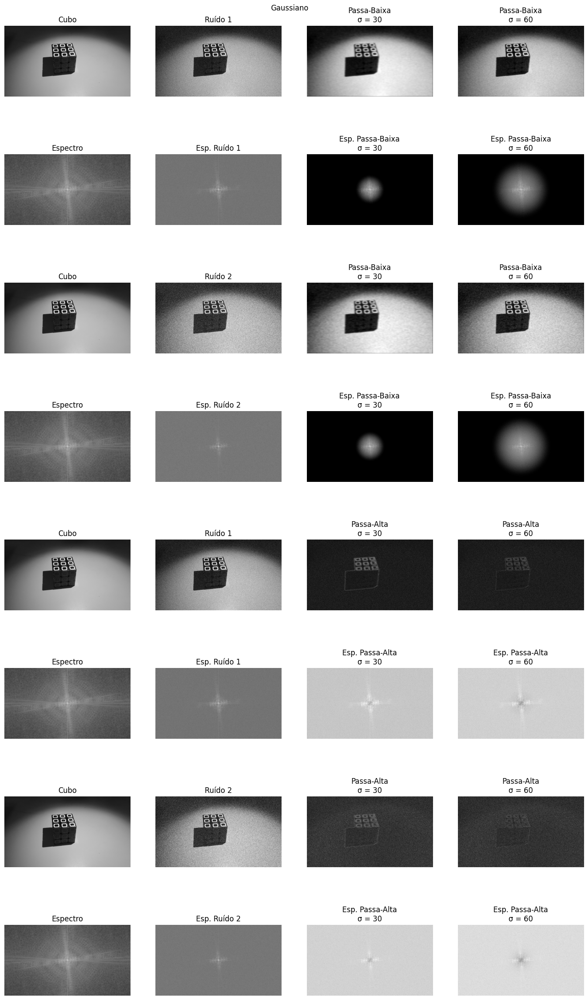

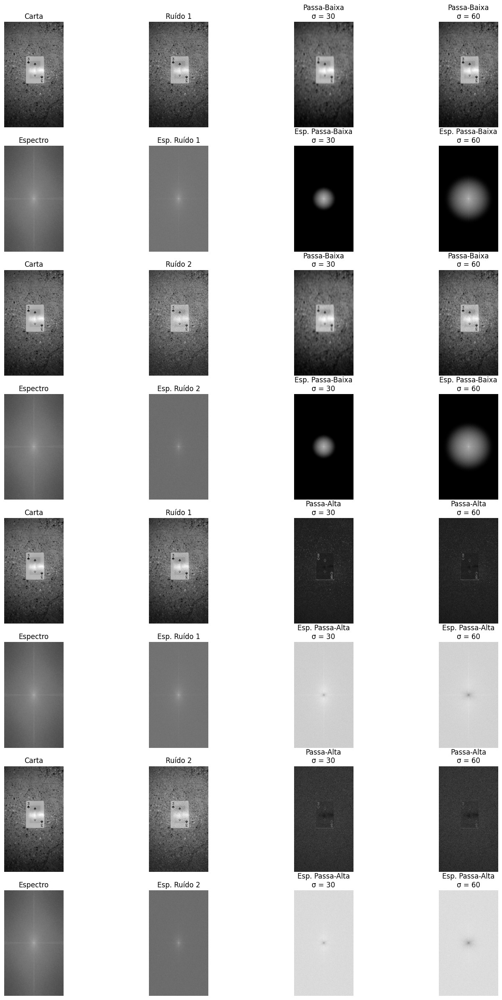

In [ ]:
# Criando a visualização para a Classe A (Cubo Mágico) com os filtros aplicados
fig_cubo, ax_cubo = vision.criar_figure('Gaussiano', 8, 4, (14, 24))
vision.preencher_figure(ax_cubo, cubo_filtrado, cmap='gray')
vision.nomear_axes(ax_cubo, nomes_cubo)
vision.remover_axis(ax_cubo.flatten())

# Criando a visualização para a Classe B (Carta) com os filtros aplicados
fig_carta, ax_carta = vision.criar_figure('', 8, 4, (14, 24))
vision.preencher_figure(ax_carta, carta_filtrado, cmap='gray')
vision.nomear_axes(ax_carta, nomes_carta)
vision.remover_axis(ax_carta.flatten())

# Aplicação de filtros para ruído Sal e Pimenta

In [ ]:
# Reaproveita: filtro = GaussFilters() e a função reconstruct() já definidas
# para o ruído gaussiano. Aqui só mudam as entradas (_sp1/_sp2) e os nomes de saída (prefixo "sp").

# PASSA BAIXA
#------------------------------------------------------------------#
cbsp1_low_30 = filtro.passa_baixa_gaussiano(cb_spec_sp1, 30)
cbsp2_low_30 = filtro.passa_baixa_gaussiano(cb_spec_sp2, 30)

cbsp1_low_60 = filtro.passa_baixa_gaussiano(cb_spec_sp1, 60)
cbsp2_low_60 = filtro.passa_baixa_gaussiano(cb_spec_sp2, 60)

ctsp1_low_30 = filtro.passa_baixa_gaussiano(ct_spec_sp1, 30)
ctsp2_low_30 = filtro.passa_baixa_gaussiano(ct_spec_sp2, 30)

ctsp1_low_60 = filtro.passa_baixa_gaussiano(ct_spec_sp1, 60)
ctsp2_low_60 = filtro.passa_baixa_gaussiano(ct_spec_sp2, 60)
#------------------------------------------------------------------#

# PASSA ALTA
#------------------------------------------------------------------#
cbsp1_high_30 = filtro.passa_alta_gaussiano(cb_spec_sp1, 30)
cbsp2_high_30 = filtro.passa_alta_gaussiano(cb_spec_sp2, 30)

cbsp1_high_60 = filtro.passa_alta_gaussiano(cb_spec_sp1, 60)
cbsp2_high_60 = filtro.passa_alta_gaussiano(cb_spec_sp2, 60)

ctsp1_high_30 = filtro.passa_alta_gaussiano(ct_spec_sp1, 30)
ctsp2_high_30 = filtro.passa_alta_gaussiano(ct_spec_sp2, 30)

ctsp1_high_60 = filtro.passa_alta_gaussiano(ct_spec_sp1, 60)
ctsp2_high_60 = filtro.passa_alta_gaussiano(ct_spec_sp2, 60)
#------------------------------------------------------------------#

# APLICAÇÃO DOS FILTROS NO DOMÍNIO DA FREQUÊNCIA (SHIFTADO)
#------------------------------------------------------------------#
f_cbsp1 = np.fft.fftshift(np.fft.fft2(cb_gray_sp1))
f_cbsp2 = np.fft.fftshift(np.fft.fft2(cb_gray_sp2))
f_ctsp1 = np.fft.fftshift(np.fft.fft2(ct_gray_sp1))
f_ctsp2 = np.fft.fftshift(np.fft.fft2(ct_gray_sp2))

# Filtragem Passa-Baixa
cbsp1_l30_f = f_cbsp1 * cbsp1_low_30
cbsp1_l60_f = f_cbsp1 * cbsp1_low_60
cbsp2_l30_f = f_cbsp2 * cbsp2_low_30
cbsp2_l60_f = f_cbsp2 * cbsp2_low_60

ctsp1_l30_f = f_ctsp1 * ctsp1_low_30
ctsp1_l60_f = f_ctsp1 * ctsp1_low_60
ctsp2_l30_f = f_ctsp2 * ctsp2_low_30
ctsp2_l60_f = f_ctsp2 * ctsp2_low_60

# Filtragem Passa-Alta
cbsp1_h30_f = f_cbsp1 * cbsp1_high_30
cbsp1_h60_f = f_cbsp1 * cbsp1_high_60
cbsp2_h30_f = f_cbsp2 * cbsp2_high_30
cbsp2_h60_f = f_cbsp2 * cbsp2_high_60

ctsp1_h30_f = f_ctsp1 * ctsp1_high_30
ctsp1_h60_f = f_ctsp1 * ctsp1_high_60
ctsp2_h30_f = f_ctsp2 * ctsp2_high_30
ctsp2_h60_f = f_ctsp2 * ctsp2_high_60

# Imagens reconstruídas (domínio espacial) — usa a reconstruct() já definida
cbsp1_l30_img = reconstruct(cbsp1_l30_f)
cbsp1_l60_img = reconstruct(cbsp1_l60_f)
cbsp2_l30_img = reconstruct(cbsp2_l30_f)
cbsp2_l60_img = reconstruct(cbsp2_l60_f)

ctsp1_l30_img = reconstruct(ctsp1_l30_f)
ctsp1_l60_img = reconstruct(ctsp1_l60_f)
ctsp2_l30_img = reconstruct(ctsp2_l30_f)
ctsp2_l60_img = reconstruct(ctsp2_l60_f)

cbsp1_h30_img = reconstruct(cbsp1_h30_f)
cbsp1_h60_img = reconstruct(cbsp1_h60_f)
cbsp2_h30_img = reconstruct(cbsp2_h30_f)
cbsp2_h60_img = reconstruct(cbsp2_h60_f)

ctsp1_h30_img = reconstruct(ctsp1_h30_f)
ctsp1_h60_img = reconstruct(ctsp1_h60_f)
ctsp2_h30_img = reconstruct(ctsp2_h30_f)
ctsp2_h60_img = reconstruct(ctsp2_h60_f)

# Espectros filtrados para visualização
specl_cbsp1_30 = np.log(1 + np.abs(cbsp1_l30_f))
specl_cbsp1_60 = np.log(1 + np.abs(cbsp1_l60_f))
specl_cbsp2_30 = np.log(1 + np.abs(cbsp2_l30_f))
specl_cbsp2_60 = np.log(1 + np.abs(cbsp2_l60_f))

spech_cbsp1_30 = np.log(1 + np.abs(cbsp1_h30_f))
spech_cbsp1_60 = np.log(1 + np.abs(cbsp1_h60_f))
spech_cbsp2_30 = np.log(1 + np.abs(cbsp2_h30_f))
spech_cbsp2_60 = np.log(1 + np.abs(cbsp2_h60_f))

specl_ctsp1_30 = np.log(1 + np.abs(ctsp1_l30_f))
specl_ctsp1_60 = np.log(1 + np.abs(ctsp1_l60_f))
specl_ctsp2_30 = np.log(1 + np.abs(ctsp2_l30_f))
specl_ctsp2_60 = np.log(1 + np.abs(ctsp2_l60_f))

spech_ctsp1_30 = np.log(1 + np.abs(ctsp1_h30_f))
spech_ctsp1_60 = np.log(1 + np.abs(ctsp1_h60_f))
spech_ctsp2_30 = np.log(1 + np.abs(ctsp2_h30_f))
spech_ctsp2_60 = np.log(1 + np.abs(ctsp2_h60_f))
#------------------------------------------------------------------#

cubo_filtrado_sp = [
    # Passa_Baixa (Imagens espaciais)
    [cb_gray, cb_gray_sp1, cbsp1_l30_img, cbsp1_l60_img],
    # Espectros Passa_Baixa
    [cb_spec, cb_spec_sp1, specl_cbsp1_30, specl_cbsp1_60],
    # Passa_Baixa Sal e Pimenta 2 (Imagens espaciais)
    [cb_gray, cb_gray_sp2, cbsp2_l30_img, cbsp2_l60_img],
    # Espectros Passa_Baixa
    [cb_spec, cb_spec_sp2, specl_cbsp2_30, specl_cbsp2_60],
    # Passa_Alta (Imagens espaciais)
    [cb_gray, cb_gray_sp1, cbsp1_h30_img, cbsp1_h60_img],
    # Espectros Passa_Alta
    [cb_spec, cb_spec_sp1, spech_cbsp1_30, spech_cbsp1_60],
    # Passa_Alta Sal e Pimenta 2 (Imagens espaciais)
    [cb_gray, cb_gray_sp2, cbsp2_h30_img, cbsp2_h60_img],
    # Espectros Passa_Alta
    [cb_spec, cb_spec_sp2, spech_cbsp2_30, spech_cbsp2_60]
]

carta_filtrado_sp = [
    # Passa_Baixa (Imagens espaciais)
    [ct_gray, ct_gray_sp1, ctsp1_l30_img, ctsp1_l60_img],
    # Espectros Passa_Baixa
    [ct_spec, ct_spec_sp1, specl_ctsp1_30, specl_ctsp1_60],
    # Passa_Baixa Sal e Pimenta 2 (Imagens espaciais)
    [ct_gray, ct_gray_sp2, ctsp2_l30_img, ctsp2_l60_img],
    # Espectros Passa_Baixa
    [ct_spec, ct_spec_sp2, specl_ctsp2_30, specl_ctsp2_60],
    # Passa_Alta (Imagens espaciais)
    [ct_gray, ct_gray_sp1, ctsp1_h30_img, ctsp1_h60_img],
    # Espectros Passa_Alta
    [ct_spec, ct_spec_sp1, spech_ctsp1_30, spech_ctsp1_60],
    # Passa_Alta Sal e Pimenta 2 (Imagens espaciais)
    [ct_gray, ct_gray_sp2, ctsp2_h30_img, ctsp2_h60_img],
    # Espectros Passa_Alta
    [ct_spec, ct_spec_sp2, spech_ctsp2_30, spech_ctsp2_60]
]

nomes_cubo = [
    # Passa_Baixa
    ["Cubo", "Ruído 1", "Passa-Baixa\nσ = 30", "Passa-Baixa\nσ = 60"],
    ["Espectro", "Esp. Ruído 1", "Esp. Passa-Baixa\nσ = 30", "Esp. Passa-Baixa\nσ = 60"],
    ["Cubo", "Ruído 2", "Passa-Baixa\nσ = 30", "Passa-Baixa\nσ = 60"],
    ["Espectro", "Esp. Ruído 2", "Esp. Passa-Baixa\nσ = 30", "Esp. Passa-Baixa\nσ = 60"],
    # Passa_Alta
    ["Cubo", "Ruído 1", "Passa-Alta\nσ = 30", "Passa-Alta\nσ = 60"],
    ["Espectro", "Esp. Ruído 1", "Esp. Passa-Alta\nσ = 30", "Esp. Passa-Alta\nσ = 60"],
    ["Cubo", "Ruído 2", "Passa-Alta\nσ = 30", "Passa-Alta\nσ = 60"],
    ["Espectro", "Esp. Ruído 2", "Esp. Passa-Alta\nσ = 30", "Esp. Passa-Alta\nσ = 60"]
]

nomes_carta = [
    # Passa_Baixa
    ["Carta", "Ruído 1", "Passa-Baixa\nσ = 30", "Passa-Baixa\nσ = 60"],
    ["Espectro", "Esp. Ruído 1", "Esp. Passa-Baixa\nσ = 30", "Esp. Passa-Baixa\nσ = 60"],
    ["Carta", "Ruído 2", "Passa-Baixa\nσ = 30", "Passa-Baixa\nσ = 60"],
    ["Espectro", "Esp. Ruído 2", "Esp. Passa-Baixa\nσ = 30", "Esp. Passa-Baixa\nσ = 60"],
    # Passa_Alta
    ["Carta", "Ruído 1", "Passa-Alta\nσ = 30", "Passa-Alta\nσ = 60"],
    ["Espectro", "Esp. Ruído 1", "Esp. Passa-Alta\nσ = 30", "Esp. Passa-Alta\nσ = 60"],
    ["Carta", "Ruído 2", "Passa-Alta\nσ = 30", "Passa-Alta\nσ = 60"],
    ["Espectro", "Esp. Ruído 2", "Esp. Passa-Alta\nσ = 30", "Esp. Passa-Alta\nσ = 60"]
]

nomes_cubo_sp = [
    # Passa_Baixa
    ["Cubo", "S&P 1", "Passa-Baixa\nσ = 30", "Passa-Baixa\nσ = 60"],
    ["Espectro", "Esp. S&P 1", "Esp. Passa-Baixa\nσ = 30", "Esp. Passa-Baixa\nσ = 60"],
    ["Cubo", "S&P 2", "Passa-Baixa\nσ = 30", "Passa-Baixa\nσ = 60"],
    ["Espectro", "Esp. S&P 2", "Esp. Passa-Baixa\nσ = 30", "Esp. Passa-Baixa\nσ = 60"],
    # Passa_Alta
    ["Cubo", "S&P 1", "Passa-Alta\nσ = 30", "Passa-Alta\nσ = 60"],
    ["Espectro", "Esp. S&P 1", "Esp. Passa-Alta\nσ = 30", "Esp. Passa-Alta\nσ = 60"],
    ["Cubo", "S&P 2", "Passa-Alta\nσ = 30", "Passa-Alta\nσ = 60"],
    ["Espectro", "Esp. S&P 2", "Esp. Passa-Alta\nσ = 30", "Esp. Passa-Alta\nσ = 60"]
]

nomes_carta_sp = [
    # Passa_Baixa
    ["Carta", "S&P 1", "Passa-Baixa\nσ = 30", "Passa-Baixa\nσ = 60"],
    ["Espectro", "Esp. S&P 1", "Esp. Passa-Baixa\nσ = 30", "Esp. Passa-Baixa\nσ = 60"],
    ["Carta", "S&P 2", "Passa-Baixa\nσ = 30", "Passa-Baixa\nσ = 60"],
    ["Espectro", "Esp. S&P 2", "Esp. Passa-Baixa\nσ = 30", "Esp. Passa-Baixa\nσ = 60"],
    # Passa_Alta
    ["Carta", "S&P 1", "Passa-Alta\nσ = 30", "Passa-Alta\nσ = 60"],
    ["Espectro", "Esp. S&P 1", "Esp. Passa-Alta\nσ = 30", "Esp. Passa-Alta\nσ = 60"],
    ["Carta", "S&P 2", "Passa-Alta\nσ = 30", "Passa-Alta\nσ = 60"],
    ["Espectro", "Esp. S&P 2", "Esp. Passa-Alta\nσ = 30", "Esp. Passa-Alta\nσ = 60"]
]

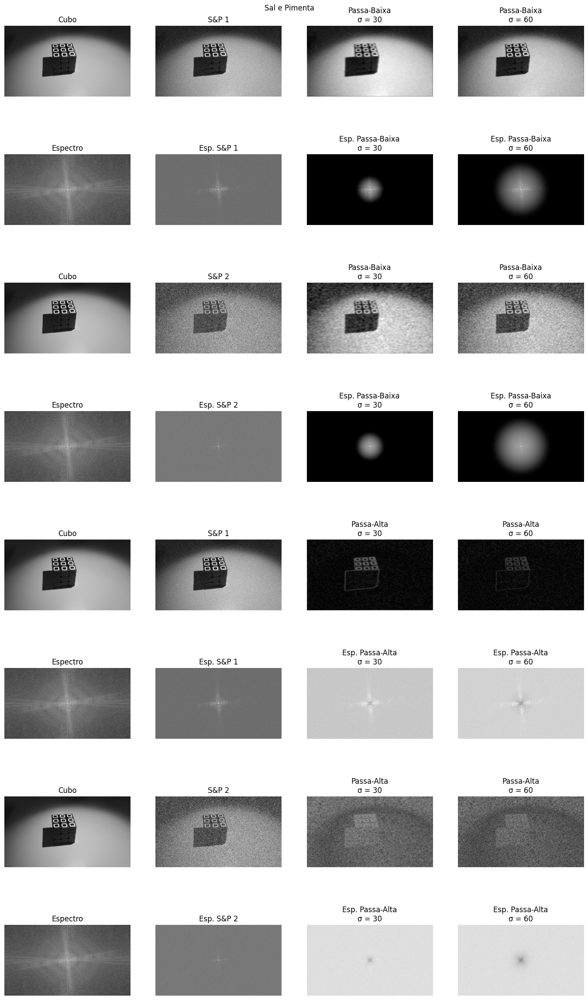

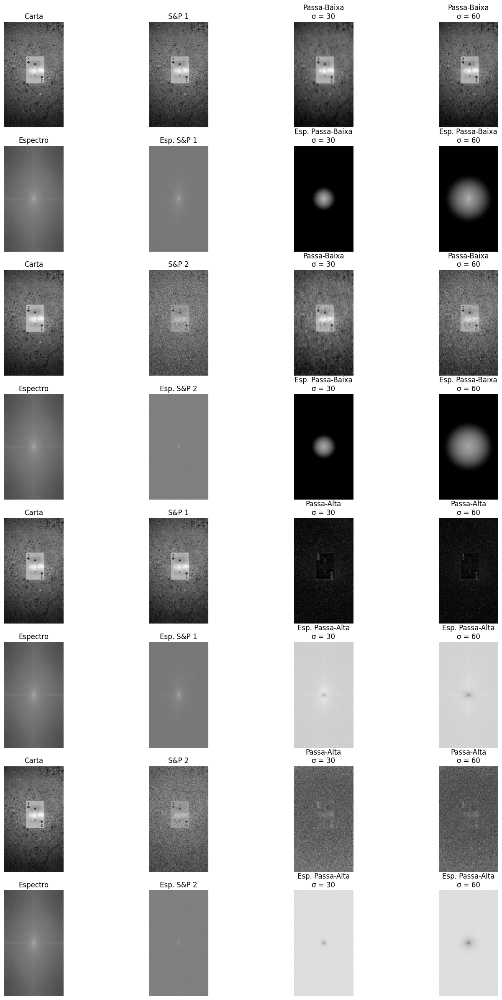

In [ ]:
# Reutilizando lógica de visualização
fig_cubo_sp, ax_cubo_sp = vision.criar_figure('Sal e Pimenta', 8, 4, (14, 24))
vision.preencher_figure(ax_cubo_sp, cubo_filtrado_sp, cmap='gray')
vision.nomear_axes(ax_cubo_sp, nomes_cubo_sp)
vision.remover_axis(ax_cubo_sp.flatten())

fig_carta_sp, ax_carta_sp = vision.criar_figure('', 8, 4, (14, 24))
vision.preencher_figure(ax_carta_sp, carta_filtrado_sp, cmap='gray')
vision.nomear_axes(ax_carta_sp, nomes_carta_sp)
vision.remover_axis(ax_carta_sp.flatten())

# Registro da aplicação de filtros:


### Que detalhes da imagem foram perdidos por conta dos ruídos:

  * Ruído Gaussiano:

    * Na imagem carta1.jpeg, o fundo perdeu nitidez, e as rachaduras no chão ficaram menos visíveis. Isso acontece porque o ruído gaussiano altera a intensidade de todos os pixels, misturando os pequenos detalhes do fundo com a granulação do ruído.
    * Na imagem cubo4.jpeg, a parte sombreada do cubo perdeu os detalhes, impossibilitando a detecção de bordas naquela região. Como a região já tinha pouco contraste, o ruído acabou "encobrindo" as poucas variações de intensidade que existiam ali.

  * Ruído Sal e Pimenta:

    * Nesse caso, os pixels brancos e pretos espalhados pela imagem substituíram completamente o valor original dos pixels afetados. Assim, os detalhes finos, como as bordas dos números da carta e as texturas do fundo, foram interrompidos por pontos isolados de intensidade extrema. Com o ruído mais forte (ruído 2), isso ficou ainda mais evidente: a imagem original quase não pôde mais ser distinguida do ruído, principalmente nas regiões escuras e de baixo contraste, como a sombra do cubo.

### Que estruturas da imagem foram destacadas:

  * Passa-Baixa: O filtro destacou as estruturas de baixa frequência, ou seja, as regiões grandes e com variação suave de intensidade. Como exemplo, no cubo, foram preservados o formato geral do objeto, a sombra ao redor e a iluminação do fundo. Já os detalhes finos e o ruído foram atenuados.

  * Passa-Alta: O filtro destacou as estruturas de alta frequência, ou seja, os pontos onde há mudanças bruscas de intensidade. Como exemplo, no cubo, foram destacados os contornos e as quinas do objeto, além dos furos da face superior. Na carta, foram destacados os contornos da carta e das figuras impressas nela. As regiões uniformes, como o fundo liso, praticamente desapareceram.

### As bordas ficaram mais visíveis:

  * Passa-Baixa: Não. Pelo contrário, as bordas ficaram mais suaves e menos definidas, já que elas são formadas por variações bruscas de intensidade, que são justamente o que esse filtro atenua. Esse efeito ficou mais forte com o valor de sigma menor (σ = 30), que mantém apenas as frequências mais baixas.

  * Passa-Alta: Sim, mas com uma condição. Nas imagens onde o ruído era mais fraco, as bordas ficaram bem mais visíveis. Todavia, como o ruído também é um sinal de alta frequência, o filtro acabou realçando o próprio ruído junto com as bordas. Por isso, com o ruído sal e pimenta mais forte, as bordas deixaram de ser distinguíveis. Além disso, o valor de sigma maior (σ = 60) removeu mais frequências baixas e médias, o que explica a perda de algumas bordas, como as dos números da carta.

### Esses tipos de filtros ajudariam em quais tarefas de visão computacional:

  * Passa-Baixa:

    * Pré-processamento para reduzir ruído antes de outras etapas, como a detecção de bordas.
    * Segmentação de regiões grandes, como separar objeto e fundo, já que os detalhes finos deixam de atrapalhar.
    * Redução de resolução de imagens (downsampling), evitando artefatos.

  * Passa-Alta:

    * Detecção de bordas e contornos, que é a base de várias outras tarefas.
    * Extração de características, como cantos e texturas, usadas no reconhecimento de objetos.
    * Realce de nitidez (sharpening) e leitura de textos e símbolos, como os números e naipes de uma carta.

  * Como o passa-alta amplifica o ruído, o ideal é aplicar primeiro um passa-baixa leve e só depois o passa-alta, o que é comum em pipelines de detecção de bordas.

# Tabela de Comparação:

### ```cubo4.jpeg```

**Imagem original:**

- A imagem original estava num cenário de iluminação artificial. As bordas não estavam extremamente destacadas, mas estavam suficientemente nítidas na imagem, devido ao fundo branco. A sombra semi-circular acima do cubo estava suave. A parte sombreada do cubo, apesar de estar escura, ainda era bastante visível e os pequenos cubos ainda eram perceptíveis na imagem.

**Imagem com ruído gaussiano:**

 - O ruído gaussiano deixou a imagem meio granulada e fez com que a parte sombreada do cubo perdesse mais dos detalhes, eventualmente ficando impossível de se visualizar. A sombra acima do cubo ficou menos suave, sendo afetada pela granulação.

**Imagem com ruído sal e pimenta:**

- O ruído sal e pimenta espalhou pontos brancos e pretos por toda a imagem. Quando o ruído era mais leve, o cubo continuou bem identificável, com os furos da face superior ainda visíveis. Com a intensificação do ruído, a imagem ficou muito mais salpicada, e a granulação tomou conta tanto do fundo quanto da parte sombreada do cubo, que perdeu quase todos os seus detalhes. A sombra ao redor do cubo também perdeu a suavidade que tinha na imagem original.

**Imagem filtrada com gaussiano:**

- Nas imagens com ruído gaussiano, o filtro Passa-Baixa foi bastante eficaz. Com σ = 30, a granulação praticamente desapareceu e o fundo voltou a ficar suave, mas as bordas do cubo e os furos da face superior ficaram borrados. Com σ = 60, o cubo manteve mais nitidez, embora tenha restado um pouco de granulação na imagem. Já nas imagens com ruído sal e pimenta, o efeito foi menor. O filtro transformou os pontos isolados em manchas, deixando a imagem mais natural, mas ainda ruidosa, e a granulação ficou mais presente com σ = 60. Em ambos os casos, o formato geral do cubo e a sombra ao redor foram recuperados, mas os detalhes finos não foram.

**Imagem com filtro passa-alta:**

- Quando o ruído era fraco, o filtro Passa-Alta conseguiu destacar os contornos do cubo, os furos da face superior e o limite da sombra, enquanto o fundo, que é uma região mais uniforme, ficou praticamente todo escuro. Todavia, as bordas da parte sombreada do cubo não foram detectadas, sendo destacadas apenas as da parte superior. Com σ = 60, as bordas ficaram ainda mais fracas do que com σ = 30, o que mostra que o filtro funcionou melhor com o valor menor. Quando o ruído era forte, o filtro não funcionou, já que o próprio ruído também é uma variação brusca de intensidade e acabou sendo realçado junto com as bordas, impossibilitando a detecção.

---

### ```carta1.jpeg```

**Imagem original:**

- A imagem original mostra uma carta (o 3 de espadas) sobre um chão escuro e bastante texturizado, com rachaduras e pequenas manchas. A carta é a região mais clara da imagem, o que faz ela se destacar bem do fundo, e os números e naipes dos cantos estavam nítidos. Havia um reflexo de luz no centro da carta, que deixou essa região mais clara e apagou parte dos detalhes ali. Além disso, as bordas da imagem eram mais escuras que o centro.

**Imagem com ruído gaussiano:**

- O ruído gaussiano deixou a imagem granulada, e o fundo perdeu nitidez, fazendo com que as rachaduras no chão ficassem menos visíveis. Como o fundo já era bastante texturizado, a granulação se misturou com as manchas do chão, dificultando distinguir o que era ruído e o que era detalhe. A carta continuou identificável, mas o número e os naipes ficaram menos nítidos.

**Imagem com ruído sal e pimenta:**

- Quando o ruído era fraco, o efeito foi bem discreto: a imagem ficou muito parecida com a original, e os pontos brancos e pretos se confundiram com a textura do próprio chão, que já tinha manchas claras e escuras. A carta, o número e os naipes continuaram bem visíveis. Isso mostra que um fundo texturizado ajuda a "esconder" esse tipo de ruído quando ele é fraco. Com o ruído mais forte, os pontos passaram a tomar conta da imagem, prejudicando os detalhes finos, como o número e os naipes.

**Imagem filtrada com gaussiano:**

- O filtro Passa-Baixa suavizou a imagem, mas isso teve um custo. Com σ = 30, a imagem ficou bem borrada: o fundo perdeu as rachaduras e as manchas, e a carta perdeu a nitidez, com o número e os naipes ficando difíceis de identificar. Com σ = 60, a carta manteve mais detalhes, e o número e os naipes ainda puderam ser reconhecidos, embora o fundo também tenha perdido um pouco da textura. Assim como no cubo, o valor de sigma maior teve um melhor equilíbrio entre suavização e preservação de detalhes. Isso ocorreu tanto nas imagens com ruído gaussiano quanto nas com sal e pimenta.

**Imagem com filtro passa-alta:**

- No caso da carta, o filtro Passa-Alta funcionou melhor com o valor menor de sigma (σ = 30). Quando o ruído era fraco, foi possível perceber o contorno da carta e as marcas dos naipes, enquanto o fundo ficou escuro, com apenas um pouco de granulação. Com σ = 60, os contornos ficaram ainda mais fracos, quase imperceptíveis. Quando o ruído era forte, o filtro não funcionou bem: o fundo ficou acinzentado e ruidoso, e o contorno da carta só pôde ser percebido de forma bem fraca, sem destacar os detalhes do número e dos naipes.

## Conclusão:

### Qual ruído degradou mais a imagem:

  * O ruído sal e pimenta foi o que mais degradou as imagens, principalmente quando estava mais forte. Isso acontece porque ele substitui completamente o valor dos pixels afetados por preto ou branco, apagando a informação original desses pontos. Já o ruído gaussiano apenas soma uma variação aleatória ao valor de cada pixel, então a informação original continua ali, só que "embaralhada". Analisando o cubo, com o ruído sal e pimenta forte a granulação tomou conta da imagem inteira e a parte sombreada do cubo perdeu quase todos os seus detalhes, enquanto o ruído gaussiano deixou a imagem granulada, mas com o cubo ainda bem identificável.

  * Todavia, com o ruído sal e pimenta fraco, o efeito foi bem discreto, principalmente na imagem da carta, onde o fundo já era texturizado e os pontos brancos e pretos se confundiram com as manchas do chão. Portanto, a intensidade do ruído e o tipo de fundo da imagem também influenciam bastante o quanto a imagem é prejudicada.

### O filtro gaussiano conseguiu recuperar a qualidade visual:

  * Em parte. Nas imagens com ruído gaussiano, o filtro Passa-Baixa teve uma boa eficácia: a granulação praticamente desapareceu e o fundo voltou a ficar suave. Nas imagens com ruído sal e pimenta, o efeito foi menor: o filtro transformou os pontos isolados em manchas, deixando a imagem com uma aparência mais natural, mas ainda ruidosa.

  * A recuperação teve um custo. Como o filtro atenua as frequências altas, ele não distingue o que é ruído do que é detalhe, e assim as bordas e os detalhes finos também foram suavizados. Na carta, por exemplo, o fundo perdeu as rachaduras e o número e os naipes ficaram difíceis de identificar com σ = 30. Além disso, os detalhes que o ruído já havia apagado, como a parte sombreada do cubo, não foram recuperados.

  * O valor de σ = 60 apresentou o melhor equilíbrio entre suavização e preservação de detalhes, tanto no cubo quanto na carta. Já para o filtro Passa-Alta, o funcionamento foi melhor com σ = 30, e ele só teve um bom resultado quando o ruído era fraco, já que o filtro acaba realçando o próprio ruído junto com as bordas.

### Em quais aplicações de visão computacional seria importante aplicar filtros antes do processamento:

  * Detecção de bordas e contornos: como o filtro Passa-Alta amplifica o ruído, é importante aplicar antes um filtro Passa-Baixa leve, para que o ruído não seja confundido com bordas.

  * Reconhecimento de texto e símbolos (OCR): como a leitura dos números e naipes de uma carta, que se perde facilmente com o ruído.

  * Detecção e classificação de objetos: o ruído pode gerar falsas detecções ou esconder características importantes do objeto.

  * Segmentação de imagens: como separar objeto e fundo, onde o ruído pode espalhar pixels de uma região para outra.

  * Imagens capturadas em condições ruins, como pouca iluminação: a câmera aumenta a sensibilidade do sensor e gera mais ruído. Exemplos são a vigilância por câmeras e a visão de veículos autônomos à noite.

  * Imagens médicas e inspeção industrial: onde pequenos detalhes precisam ser identificados com precisão, e o ruído pode levar a erros de diagnóstico ou de detecção de defeitos.

  * Vale lembrar que o filtro deve ser escolhido de acordo com o tipo de ruído e com o quanto de detalhe precisa ser preservado.